Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Full dataset shape: (2138040, 79)

Original class distribution:
Mapped_Label
0    1833066
2     158930
1     128027
3      18017
Name: count, dtype: int64

Minimum class size: 18017
Sampling per class: 16215


/tmp/ipython-input-3359046294.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("Mapped_Label", group_keys=False).apply(



Balanced class distribution:
Mapped_Label
0    16215
1    16215
2    16215
3    16215
Name: count, dtype: int64
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Mapped_Label                     int64
Length: 80, dtype: object
Feature shape: (64860, 78)
Target shape: (64860,)
Train shape: (51888, 78)
Test shape: (12972, 78)
Tensor conversion complete.
Training class counts: [12972 12972 12972 12972]
Class weights: tensor([0.2500, 0.2500, 0.2500, 0.2500])
Model initialized.
Epoch [1/15] Loss: 96.4719 Train Accuracy: 0.9314
Epoch [2/15] Loss: 38.8604 Train Accuracy: 0.9720
Epoch [3/15] Loss: 30.0326 Train Accuracy: 0.9775
Epoch [4/15] Loss: 25.0038 Trai

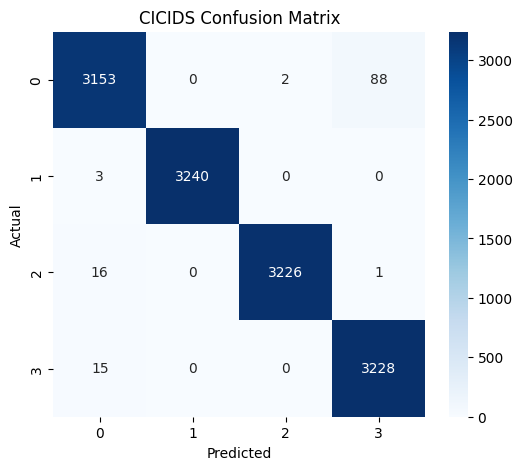

Total SHAP time: 36.70258641242981
SHAP time per sample: 0.3670258641242981
Raw SHAP shape: (100, 1, 78, 4)
Processed SHAP shape: (100, 78, 4)


/tmp/ipython-input-3359046294.py:338: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_global, features, show=True)


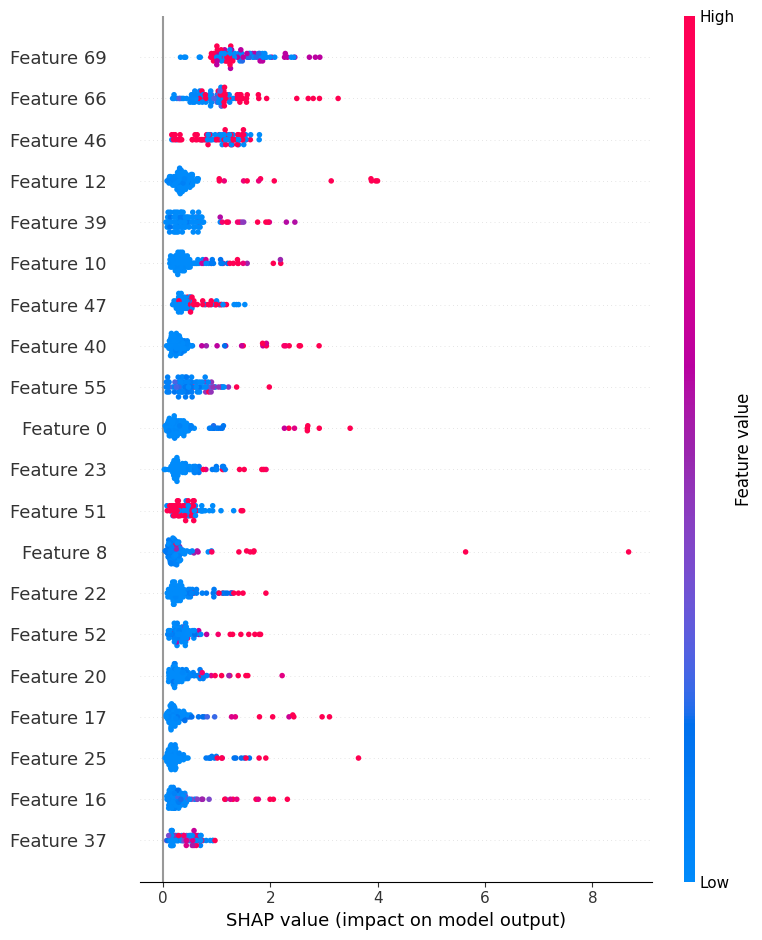


CICIDS SHAP Stability Results:
Mean Spearman Rank Correlation: 0.2765760460154673
Mean Top-K Feature Overlap: 0.9
Mean SHAP Importance Variance: 0.0008106911634336847
CICIDS SHAP stability metrics saved.


In [4]:
import pandas as pd
import numpy as np
import os
import torch
import numpy as np
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

cicids_path = "/content/drive/MyDrive/CICIDS2017/"

files = [
    f for f in os.listdir(cicids_path)
    if f.endswith(".csv") and "WorkingHours" in f
]

df_list = []

for file in files:
    print("Loading:", file)
    temp_df = pd.read_csv(os.path.join(cicids_path, file))
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Full dataset shape:", df.shape)

df.columns = df.columns.str.strip()

def map_labels(label):

    if pd.isna(label):
        return None

    label = str(label)

    if label == "BENIGN":
        return 0
    elif "DoS" in label or "DDoS" in label:
        return 1
    elif "PortScan" in label:
        return 2
    else:
        return 3

df["Mapped_Label"] = df["Label"].apply(map_labels)

# -----------------------------
# Check class distribution
# -----------------------------
class_counts = df["Mapped_Label"].value_counts()
print("\nOriginal class distribution:")
print(class_counts)

# -----------------------------
# Determine minimum class size
# -----------------------------
min_samples = class_counts.min()
print("\nMinimum class size:", min_samples)

# Use 90% of smallest class for safety
sample_size = int(min_samples * 0.9)
print("Sampling per class:", sample_size)

# -----------------------------
# Create balanced dataset
# -----------------------------
balanced_df = df.groupby("Mapped_Label", group_keys=False).apply(
    lambda x: x.sample(n=sample_size, random_state=42)
).reset_index(drop=True)

print("\nBalanced class distribution:")
print(balanced_df["Mapped_Label"].value_counts())

print(balanced_df.dtypes)

# ============================================================
# FEATURE PREPARATION
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drop original string label
balanced_df = balanced_df.drop(columns=["Label"])

# Separate features and target
X = balanced_df.drop(columns=["Mapped_Label"])
y = balanced_df["Mapped_Label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Replace inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# -----------------------------
# Train-test split FIRST
# -----------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Fit scaler ONLY on training
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
# ============================================================
# Convert to PyTorch Tensors
# ============================================================

import torch
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Tensor conversion complete.")

# ============================================================
# Compute Class Weights
# ============================================================

class_counts = np.bincount(y_train)
print("Training class counts:", class_counts)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights_tensor)

# ============================================================
# CNN Model for CICIDS
# ============================================================

import torch.nn as nn

class CNN1D_CICIDS(nn.Module):
    def __init__(self, num_classes=4):
        super(CNN1D_CICIDS, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        return x


model = CNN1D_CICIDS(num_classes=4).to(device)
print("Model initialized.")

# ============================================================
# Training Setup
# ============================================================

import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Train Accuracy: {train_acc:.4f}")

    # ============================================================
# Evaluation
# ============================================================

from sklearn.metrics import classification_report, accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

print("\nTest Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CICIDS Confusion Matrix")
plt.show()

results_df = pd.DataFrame({
    "Dataset": ["CICIDS2017"],
    "Accuracy": [accuracy]
})

results_df.to_csv(
    "/content/drive/MyDrive/CICIDS2017/cicids_results.csv",
    index=False
)

# ============================================================
# CICIDS SHAP ANALYSIS
# ============================================================

import shap
import time
from scipy.stats import spearmanr

model.eval()

# -----------------------------
# Select background + samples
# -----------------------------
background = X_train_tensor[:200].to(device)
samples = X_test_tensor[:100].to(device)

explainer = shap.GradientExplainer(model, background)

# -----------------------------
# Compute SHAP values
# -----------------------------
start_time = time.time()
shap_values = explainer.shap_values(samples)
total_shap_time = time.time() - start_time

print("Total SHAP time:", total_shap_time)
print("SHAP time per sample:", total_shap_time / samples.shape[0])

# -----------------------------
# Process SHAP shape safely
# -----------------------------
shap_values = np.array(shap_values)
print("Raw SHAP shape:", shap_values.shape)

# Expected shape: (samples, 1, features, classes)
if shap_values.ndim == 4 and shap_values.shape[1] == 1:
    shap_values = shap_values.squeeze(1)

print("Processed SHAP shape:", shap_values.shape)

# Global importance across classes
shap_global = np.mean(np.abs(shap_values), axis=2)

features = samples.cpu().numpy().squeeze(1)

# -----------------------------
# Global Summary Plot
# -----------------------------
shap.summary_plot(shap_global, features, show=True)

# ============================================================
# CICIDS SHAP STABILITY
# ============================================================

num_runs = 8
top_k = 10

rankings = []
importance_runs = []

for run in range(num_runs):

    indices = np.random.choice(len(X_test_tensor), 100, replace=False)
    batch = X_test_tensor[indices].to(device)

    shap_vals = explainer.shap_values(batch)
    shap_vals = np.array(shap_vals)

    if shap_vals.ndim == 4 and shap_vals.shape[1] == 1:
        shap_vals = shap_vals.squeeze(1)

    shap_global_run = np.mean(np.abs(shap_vals), axis=2)
    mean_importance_run = np.mean(shap_global_run, axis=0)

    importance_runs.append(mean_importance_run)
    rankings.append(np.argsort(-mean_importance_run))


# -----------------------------
# Spearman Rank Correlation
# -----------------------------
spearman_scores = []
for i in range(num_runs):
    for j in range(i+1, num_runs):
        corr, _ = spearmanr(rankings[i], rankings[j])
        spearman_scores.append(corr)

mean_spearman = np.mean(spearman_scores)

# -----------------------------
# Top-K Overlap
# -----------------------------
overlaps = []
for i in range(num_runs):
    for j in range(i+1, num_runs):
        top_i = set(rankings[i][:top_k])
        top_j = set(rankings[j][:top_k])
        overlap = len(top_i & top_j) / top_k
        overlaps.append(overlap)

mean_overlap = np.mean(overlaps)

# -----------------------------
# SHAP Variance
# -----------------------------
importance_array = np.array(importance_runs)
mean_variance = np.mean(np.var(importance_array, axis=0))

print("\nCICIDS SHAP Stability Results:")
print("Mean Spearman Rank Correlation:", mean_spearman)
print("Mean Top-K Feature Overlap:", mean_overlap)
print("Mean SHAP Importance Variance:", mean_variance)
stability_df = pd.DataFrame({
    "Dataset": ["CICIDS2017"],
    "Mean_Spearman": [mean_spearman],
    "Mean_TopK_Overlap": [mean_overlap],
    "Mean_SHAP_Variance": [mean_variance],
    "SHAP_Time_Per_Sample": [total_shap_time / samples.shape[0]]
})

stability_df.to_csv(
    "/content/drive/MyDrive/CICIDS2017/cicids_shap_stability.csv",
    index=False
)

print("CICIDS SHAP stability metrics saved.")
